# Brain CT Hemorrhage — Exploratory Data Analysis

Explores the available CT scan data across hemorrhage types. Goals:
- Understand what each type looks like across the 3 retained channel windows
- Cross-reference imaging with labeling metadata (quality, difficulty, ROI count)
- Identify candidate preprocessing transformations that may aid downstream accuracy

## 0. Setup

In [1]:
import ast
import json
import random
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import Normalize

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("/Users/hridikpunukollu/Documents/Acads/MATH 7243/Project")
RENDERS_ROOT = PROJECT_ROOT / "renders"
LABELS_CSV   = PROJECT_ROOT / "HemorrhageLabels" / "hemorrhage-labels.csv"
RESULTS_DIR  = PROJECT_ROOT / "HemorrhageLabels"

# Channels to use (brain_window dropped as most redundant per correlation analysis)
CHANNELS = ["brain_bone_window", "subdural_window", "max_contrast_window"]
CHANNEL_LABELS = ["Brain Bone", "Subdural", "Max Contrast"]

# All 6 hemorrhage types expected
HEMORRHAGE_TYPES = [
    "epidural", "intraparenchymal", "intraventricular",
    "multi", "normal", "subarachnoid", "subdural"
]

# Map type → Results CSV filename
RESULTS_FILES = {
    "epidural":          "Results_Epidural Hemorrhage Detection_2020-11-16_21.31.26.148.csv",
    "intraparenchymal":  "Results_Intraparenchymal Hemorrhage Detection_2020-11-16_21.39.31.268.csv",
    "subarachnoid":      "Results_Subarachnoid Hemorrhage Detection_2020-11-16_21.36.18.668.csv",
    "subdural":          "Results_Subdural Hemorrhage Detection_2020-11-16_21.35.48.040.csv",
    "multi":             "Results_Multiple Hemorrhage Detection_2020-11-16_21.36.24.018.csv",
}

IMG_SIZE = (512, 512)
print("Setup complete.")

Setup complete.


## 1. Metadata Loading

In [2]:
# ── 1a. Classification labels ──────────────────────────────────────────────
labels_df = pd.read_csv(LABELS_CSV)
labels_df.set_index("Image", inplace=True)
print(f"Labels loaded: {len(labels_df):,} rows")
labels_df.head()

Labels loaded: 752,803 rows


,any,epidural,intraparenchymal,intraventricular,subarachnoid,subdural
Image,,,,,,
ID_000012eaf,0,0,0,0,0,0
ID_000039fa0,0,0,0,0,0,0
ID_00005679d,0,0,0,0,0,0
ID_00008ce3c,0,0,0,0,0,0
ID_0000950d7,0,0,0,0,0,0


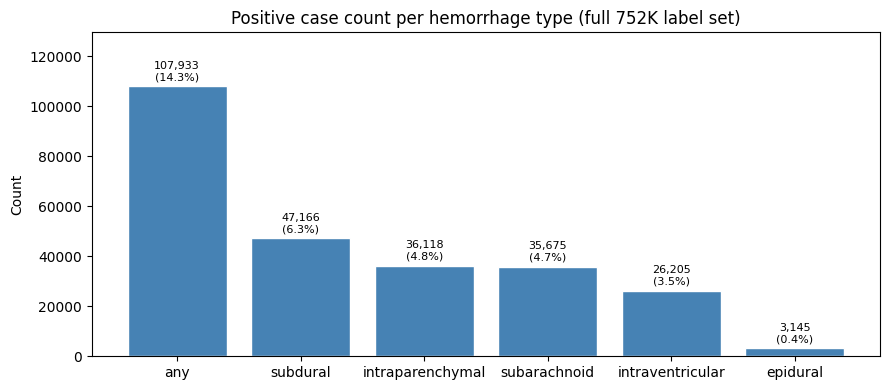


Class imbalance ratios (negative : positive):
  epidural              : 238.4:1
  intraparenchymal      : 19.8:1
  intraventricular      : 27.7:1
  subarachnoid          : 20.1:1
  subdural              : 15.0:1


In [3]:
# ── 1b. Label distribution ─────────────────────────────────────────────────
htype_cols = ["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural"]
pos_counts = labels_df[htype_cols + ["any"]].sum().sort_values(ascending=False)
total = len(labels_df)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(pos_counts.index, pos_counts.values, color="steelblue", edgecolor="white")
ax.bar_label(bars, labels=[f"{v:,}\n({v/total*100:.1f}%)" for v in pos_counts.values],
             fontsize=8, padding=3)
ax.set_title("Positive case count per hemorrhage type (full 752K label set)")
ax.set_ylabel("Count")
ax.set_ylim(0, pos_counts.max() * 1.2)
plt.tight_layout()
plt.show()

print("\nClass imbalance ratios (negative : positive):")
for col in htype_cols:
    n_pos = labels_df[col].sum()
    n_neg = total - n_pos
    print(f"  {col:<22}: {n_neg/n_pos:.1f}:1")

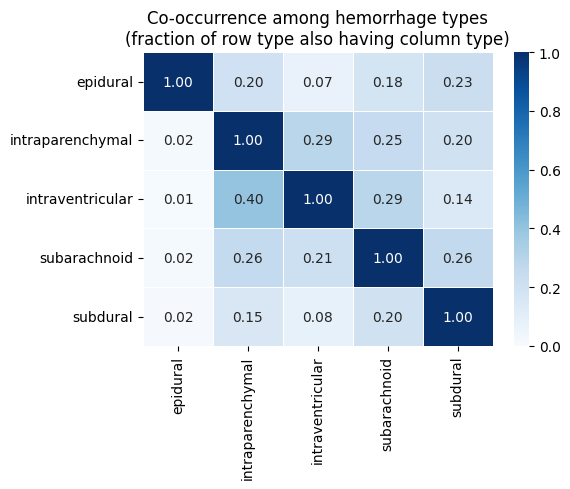

In [4]:
# ── 1c. Multi-label co-occurrence heatmap ──────────────────────────────────
# Among positive cases only
pos_df = labels_df[labels_df["any"] == 1][htype_cols]
cooccur = pos_df.T.dot(pos_df)  # (5x5) count matrix
cooccur_norm = cooccur.div(cooccur.values.diagonal(), axis=0)  # normalize by row total

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cooccur_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
            linewidths=0.5, vmin=0, vmax=1)
ax.set_title("Co-occurrence among hemorrhage types\n(fraction of row type also having column type)")
plt.tight_layout()
plt.show()

In [5]:
# ── 1d. Load Results CSVs (segmentation metadata) ──────────────────────────
def load_results(htype):
    fname = RESULTS_FILES.get(htype)
    if fname is None:
        return None
    fpath = RESULTS_DIR / fname
    if not fpath.exists():
        print(f"  [skip] {fpath.name} not found")
        return None
    df = pd.read_csv(fpath)
    df["image_id"] = df["Origin"].str.replace(".jpg", "", regex=False)
    df["htype"] = htype
    return df

results_frames = []
for ht in RESULTS_FILES:
    df = load_results(ht)
    if df is not None:
        results_frames.append(df)
        print(f"  {ht}: {len(df):,} rows")

results_df = pd.concat(results_frames, ignore_index=True) if results_frames else pd.DataFrame()
print(f"\nTotal segmentation records: {len(results_df):,}")
results_df[["image_id", "htype", "Labeling State", "Difficulty", "Agreement", "Number of ROIs"]].head()

  epidural: 610 rows


  intraparenchymal: 1,289 rows
  subarachnoid: 1,031 rows


  subdural: 752 rows


  multi: 1,054 rows

Total segmentation records: 4,736


,image_id,htype,Labeling State,Difficulty,Agreement,Number of ROIs
0,ID_004c4b319,epidural,Labeled,0.00,0.968851,1.0
1,ID_0237b835f,epidural,Ready,NaN,0.063519,1.0
2,ID_02e2d273d,epidural,Labeled,0.06,0.710300,1.0
3,ID_02f37ce84,epidural,Ready,NaN,0.264134,2.0
4,ID_02f37ce84,epidural,Ready,NaN,0.264134,2.0


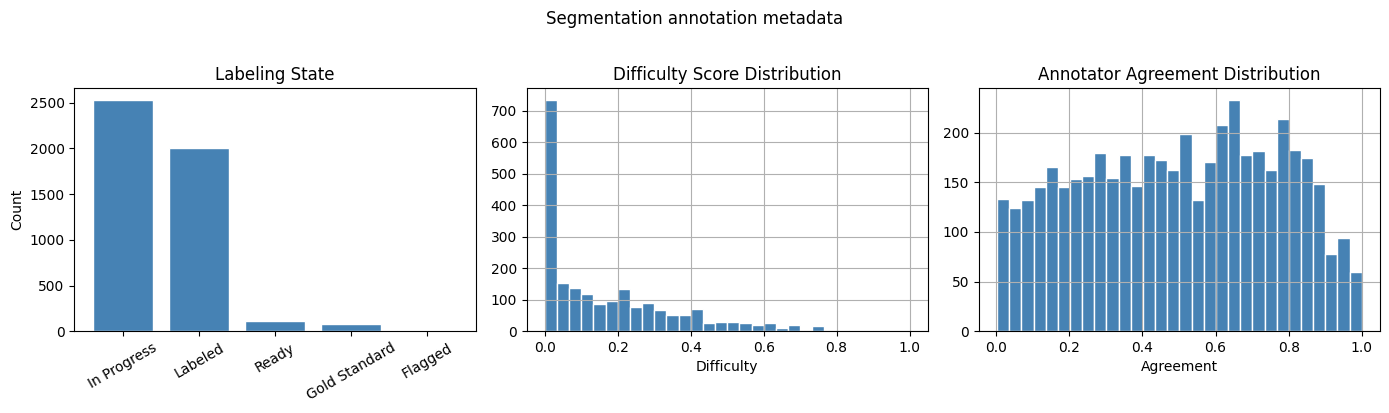

ROI count stats:
count    4736.000000
mean        2.181799
std         1.509034
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        12.000000
Name: Number of ROIs, dtype: float64


In [6]:
# ── 1e. Segmentation metadata distributions ────────────────────────────────
if len(results_df):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Labeling state breakdown
    state_counts = results_df["Labeling State"].value_counts()
    axes[0].bar(state_counts.index, state_counts.values, color="steelblue", edgecolor="white")
    axes[0].set_title("Labeling State")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=30)

    # Difficulty distribution
    results_df["Difficulty"].dropna().hist(bins=30, ax=axes[1], color="steelblue", edgecolor="white")
    axes[1].set_title("Difficulty Score Distribution")
    axes[1].set_xlabel("Difficulty")

    # Agreement distribution
    results_df["Agreement"].dropna().hist(bins=30, ax=axes[2], color="steelblue", edgecolor="white")
    axes[2].set_title("Annotator Agreement Distribution")
    axes[2].set_xlabel("Agreement")

    plt.suptitle("Segmentation annotation metadata", y=1.02)
    plt.tight_layout()
    plt.show()

    print("ROI count stats:")
    print(results_df["Number of ROIs"].describe())

## 2. Utilities

In [7]:
def load_image_3ch(image_id, htype):
    """Returns (512,512,3) uint8 array [brain_bone, subdural, max_contrast], or None."""
    channels = []
    for ch in CHANNELS:
        p = RENDERS_ROOT / htype / ch / f"{image_id}.jpg"
        if not p.exists():
            return None
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        img = cv2.resize(img, IMG_SIZE)
        channels.append(img)
    return np.stack(channels, axis=-1)  # (H,W,3) uint8


def parse_polygon(label_str):
    """Parse Majority Label / Correct Label column → list of (x,y) pixel coords."""
    if pd.isna(label_str) or label_str in ("nan", "", "[]"):
        return []
    try:
        # Try json first (Majority Label format: '[{"x":...,"y":...},...]')
        pts = json.loads(label_str)
        if pts and isinstance(pts[0], dict):
            return [(int(p["x"] * 512), int(p["y"] * 512)) for p in pts]
    except Exception:
        pass
    try:
        # Correct Label format: "[[{'x':...,'y':...},...]]" — outer list of ROIs
        rois = ast.literal_eval(label_str)
        if rois and isinstance(rois[0], list):
            # Use first ROI
            return [(int(p["x"] * 512), int(p["y"] * 512)) for p in rois[0]]
        if rois and isinstance(rois[0], dict):
            return [(int(p["x"] * 512), int(p["y"] * 512)) for p in rois]
    except Exception:
        pass
    return []


def draw_polygon_on_image(img_gray, pts, color=255, thickness=2):
    """Draw a polygon on a grayscale image (returned as BGR for matplotlib display)."""
    vis = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    if pts:
        arr = np.array(pts, dtype=np.int32).reshape((-1, 1, 2))
        cv2.polylines(vis, [arr], isClosed=True, color=(0, 0, 255), thickness=thickness)
    return vis


def get_seg_row(image_id):
    """Return the best segmentation metadata row for an image_id, or None."""
    if len(results_df) == 0:
        return None
    rows = results_df[results_df["image_id"] == image_id]
    if rows.empty:
        return None
    return rows.iloc[0]


def get_label_row(image_id):
    """Return label row for image_id, or None."""
    if image_id in labels_df.index:
        return labels_df.loc[image_id]
    return None


print("Utilities defined.")

Utilities defined.


## 3. Random Sample Visualization

For each available hemorrhage type, sample 5 images (mixing positive/negative) and show:
- All 3 channel windows
- Segmentation polygon overlay (red) on the brain-bone channel if available
- Metadata table below


  Hemorrhage Type: EPIDURAL  |  Showing 3 samples


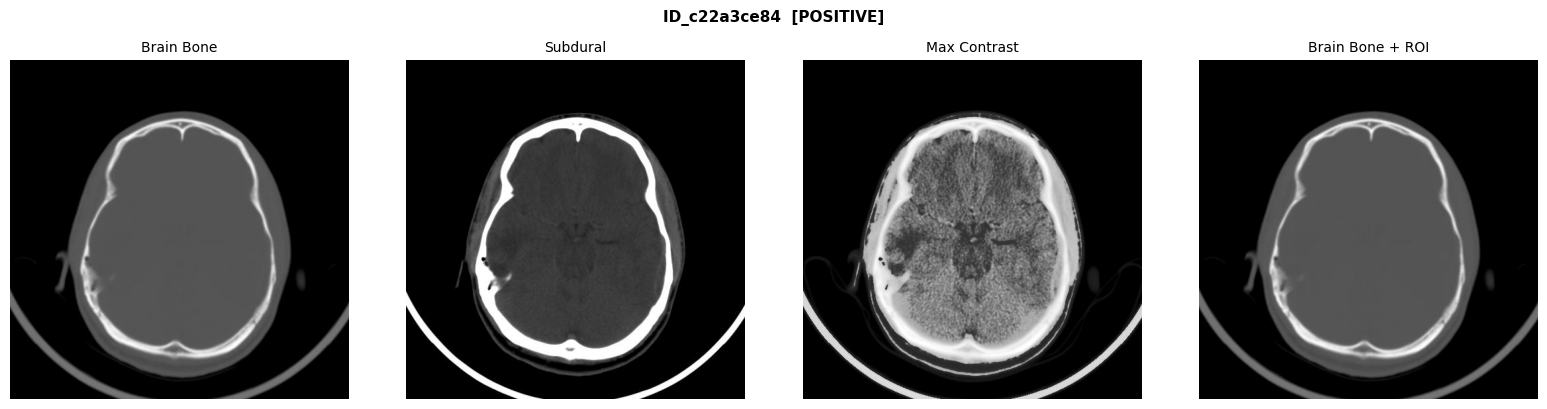

any                 1
epidural            1
intraparenchymal    0
intraventricular    0
subarachnoid        0
subdural            0



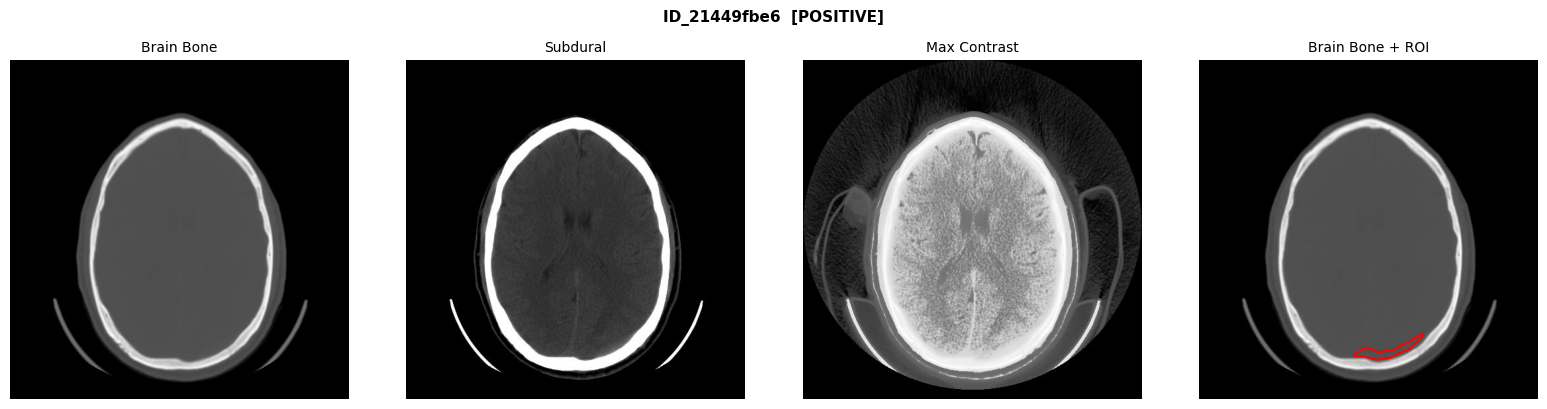

any                       1
epidural                  1
intraparenchymal          0
intraventricular          0
subarachnoid              0
subdural                  0
Labeling State      Labeled
Difficulty             0.16
Agreement             0.641
# ROIs                  1.0
ROI polygon pts         191



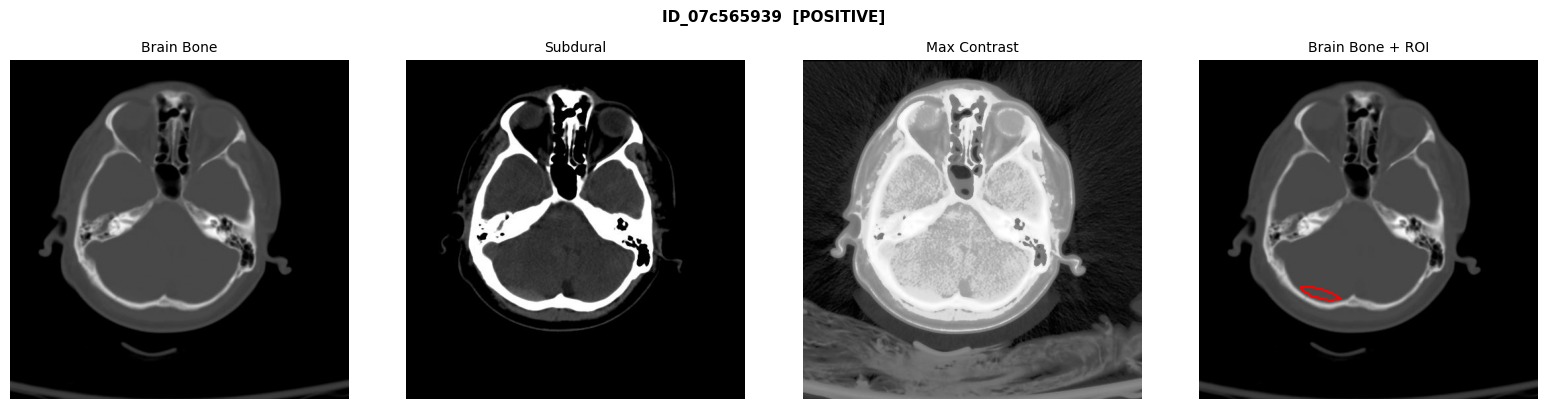

any                       1
epidural                  1
intraparenchymal          0
intraventricular          0
subarachnoid              0
subdural                  0
Labeling State      Labeled
Difficulty             0.19
Agreement               0.5
# ROIs                  1.0
ROI polygon pts         100

[intraparenchymal] images not extracted — skipping.
[intraventricular] images not extracted — skipping.
[multi] images not extracted — skipping.
[normal] images not extracted — skipping.
[subarachnoid] images not extracted — skipping.
[subdural] images not extracted — skipping.


In [8]:
N_SAMPLES = 5  # images per type

def visualize_samples(htype, n=N_SAMPLES, seed=42):
    type_dir = RENDERS_ROOT / htype / CHANNELS[0]
    if not type_dir.exists():
        print(f"[{htype}] images not extracted — skipping.")
        return

    all_ids = [p.stem for p in sorted(type_dir.glob("*.jpg"))]
    rng = random.Random(seed)

    # Try to include both positive and negative examples
    htype_col = htype if htype in labels_df.columns else None
    if htype_col:
        positives = [i for i in all_ids if i in labels_df.index and labels_df.loc[i, htype_col] == 1]
        negatives = [i for i in all_ids if i in labels_df.index and labels_df.loc[i, htype_col] == 0]
        n_pos = min(n // 2 + 1, len(positives))
        n_neg = min(n - n_pos, len(negatives))
        sample_ids = rng.sample(positives, n_pos) + rng.sample(negatives, n_neg)
        rng.shuffle(sample_ids)
    else:
        sample_ids = rng.sample(all_ids, min(n, len(all_ids)))

    print(f"\n{'='*70}")
    print(f"  Hemorrhage Type: {htype.upper()}  |  Showing {len(sample_ids)} samples")
    print(f"{'='*70}")

    for img_id in sample_ids:
        img_3ch = load_image_3ch(img_id, htype)
        if img_3ch is None:
            print(f"  [{img_id}] Could not load — skipping")
            continue

        seg_row = get_seg_row(img_id)
        lbl_row = get_label_row(img_id)

        # Parse polygon from Correct Label, fall back to Majority Label
        pts = []
        if seg_row is not None:
            for col in ["Correct Label", "Majority Label"]:
                pts = parse_polygon(str(seg_row.get(col, "nan")))
                if pts:
                    break

        # ── Figure ────────────────────────────────────────────────────────
        # 4 panels: brain_bone (with polygon), subdural, max_contrast, brain_bone raw
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        channel_names = ["Brain Bone", "Subdural", "Max Contrast"]
        for ci, (ch_name, ax) in enumerate(zip(channel_names, axes[:3])):
            gray = img_3ch[:, :, ci]
            ax.imshow(gray, cmap="gray", vmin=0, vmax=255)
            ax.set_title(ch_name, fontsize=10)
            ax.axis("off")

        # Panel 4: Brain Bone with polygon overlay
        ax = axes[3]
        vis = draw_polygon_on_image(img_3ch[:, :, 0], pts)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title("Brain Bone + ROI", fontsize=10)
        ax.axis("off")

        # Title with image ID and label
        pos_flag = ""
        if lbl_row is not None and htype_col:
            pos_flag = "  [POSITIVE]" if lbl_row.get(htype_col, 0) == 1 else "  [negative]"
        fig.suptitle(f"{img_id}{pos_flag}", fontsize=11, fontweight="bold", y=1.01)

        plt.tight_layout()
        plt.show()

        # ── Metadata table ────────────────────────────────────────────────
        meta = {}
        if lbl_row is not None:
            meta.update({c: int(lbl_row.get(c, 0)) for c in ["any"] + htype_cols})
        if seg_row is not None:
            meta["Labeling State"]  = seg_row.get("Labeling State", "—")
            meta["Difficulty"]      = round(float(seg_row.get("Difficulty", np.nan)), 3) if pd.notna(seg_row.get("Difficulty")) else "—"
            meta["Agreement"]       = round(float(seg_row.get("Agreement", np.nan)), 3) if pd.notna(seg_row.get("Agreement")) else "—"
            meta["# ROIs"]          = seg_row.get("Number of ROIs", "—")
            meta["ROI polygon pts"] = len(pts) if pts else 0
        if meta:
            print(pd.Series(meta).to_string())
        print()


# Run for all types (skips those not yet extracted)
for ht in HEMORRHAGE_TYPES:
    visualize_samples(ht)

## 4. Channel Intensity Statistics

For each available type, compute per-channel intensity distributions and compare positive vs. negative cases.

In [9]:
def compute_channel_stats(htype, max_images=1000):
    """Return DataFrame with per-image mean intensity per channel + label."""
    type_dir = RENDERS_ROOT / htype / CHANNELS[0]
    if not type_dir.exists():
        return None

    all_ids = [p.stem for p in sorted(type_dir.glob("*.jpg"))]
    rng = np.random.default_rng(42)
    if len(all_ids) > max_images:
        all_ids = [all_ids[i] for i in rng.choice(len(all_ids), max_images, replace=False)]

    records = []
    for img_id in all_ids:
        img = load_image_3ch(img_id, htype)
        if img is None:
            continue
        row = {"image_id": img_id}
        for ci, ch in enumerate(CHANNEL_LABELS):
            row[f"mean_{ch}"] = img[:, :, ci].mean()
            row[f"std_{ch}"]  = img[:, :, ci].std()
        lbl = get_label_row(img_id)
        htype_col = htype if htype in labels_df.columns else None
        row["positive"] = int(lbl.get(htype_col, 0)) if (lbl is not None and htype_col) else -1
        records.append(row)

    return pd.DataFrame(records)


intensity_frames = {}
for ht in HEMORRHAGE_TYPES:
    df = compute_channel_stats(ht)
    if df is not None and len(df):
        intensity_frames[ht] = df
        print(f"{ht}: {len(df)} images processed")

print("Done.")

epidural: 1000 images processed
Done.


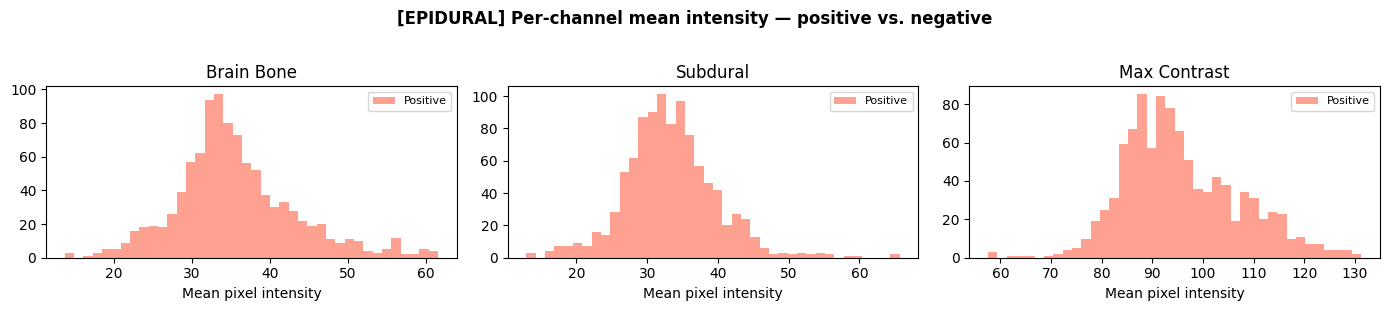

  epidural — mean intensity summary:
    Brain Bone        : pos=35.6  neg=nan  Δ=+nan
    Subdural          : pos=33.3  neg=nan  Δ=+nan
    Max Contrast      : pos=95.6  neg=nan  Δ=+nan



In [10]:
# Per-channel mean intensity: positive vs. negative
for ht, stats_df in intensity_frames.items():
    pos = stats_df[stats_df["positive"] == 1]
    neg = stats_df[stats_df["positive"] == 0]

    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ci, ch in enumerate(CHANNEL_LABELS):
        ax = axes[ci]
        col = f"mean_{ch}"
        if len(neg):
            ax.hist(neg[col], bins=40, alpha=0.6, color="royalblue", label="Negative")
        if len(pos):
            ax.hist(pos[col], bins=40, alpha=0.6, color="tomato", label="Positive")
        ax.set_title(ch)
        ax.set_xlabel("Mean pixel intensity")
        ax.legend(fontsize=8)

    fig.suptitle(f"[{ht.upper()}] Per-channel mean intensity — positive vs. negative",
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary stats
    print(f"  {ht} — mean intensity summary:")
    for ch in CHANNEL_LABELS:
        col = f"mean_{ch}"
        pmean = pos[col].mean() if len(pos) else float('nan')
        nmean = neg[col].mean() if len(neg) else float('nan')
        print(f"    {ch:<18}: pos={pmean:.1f}  neg={nmean:.1f}  Δ={pmean-nmean:+.1f}")
    print()

## 5. ROI / Segmentation Statistics

In [11]:
def polygon_to_mask(pts, size=(512, 512)):
    """Convert list of (x,y) pixel coords to binary uint8 mask."""
    mask = np.zeros(size, dtype=np.uint8)
    if len(pts) >= 3:
        arr = np.array(pts, dtype=np.int32).reshape((-1, 1, 2))
        cv2.fillPoly(mask, [arr], 255)
    return mask


if len(results_df):
    mask_stats = []
    heatmaps = {}  # htype → accumulated float mask
    heatmap_counts = {}

    for _, row in results_df.iterrows():
        pts = []
        for col in ["Correct Label", "Majority Label"]:
            pts = parse_polygon(str(row.get(col, "nan")))
            if pts:
                break
        if not pts:
            continue

        mask = polygon_to_mask(pts)
        area_pct = mask.sum() / 255 / (512 * 512) * 100

        ht = row["htype"]
        if ht not in heatmaps:
            heatmaps[ht] = np.zeros((512, 512), dtype=np.float64)
            heatmap_counts[ht] = 0
        heatmaps[ht] += (mask / 255.0)
        heatmap_counts[ht] += 1

        mask_stats.append({
            "htype": ht,
            "image_id": row["image_id"],
            "area_pct": area_pct,
            "difficulty": row.get("Difficulty", np.nan),
            "agreement": row.get("Agreement", np.nan),
        })

    mask_df = pd.DataFrame(mask_stats)
    print(f"Parsed {len(mask_df)} masks with valid polygons")
    print(mask_df.groupby("htype")["area_pct"].describe().round(2))
else:
    print("No segmentation data available.")
    mask_df = pd.DataFrame()
    heatmaps = {}

Parsed 4676 masks with valid polygons
                   count  mean   std   min   25%   50%   75%    max
htype                                                              
epidural           581.0  0.79  0.96  0.01  0.23  0.45  1.04   8.55
intraparenchymal  1268.0  0.77  1.67  0.01  0.15  0.38  0.92  31.19
multi             1054.0  0.69  0.91  0.01  0.15  0.33  0.81   6.81
subarachnoid      1030.0  0.39  0.51  0.01  0.10  0.23  0.47   6.30
subdural           743.0  0.67  0.80  0.01  0.17  0.37  0.88   6.47


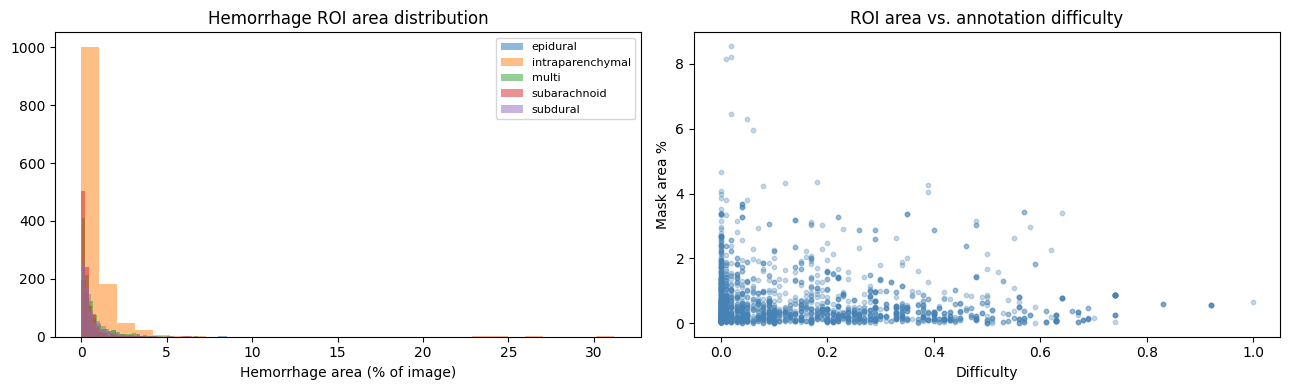

In [12]:
# Mask area vs. difficulty scatter
if len(mask_df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Distribution of mask area by type
    for ht, grp in mask_df.groupby("htype"):
        axes[0].hist(grp["area_pct"], bins=30, alpha=0.5, label=ht)
    axes[0].set_xlabel("Hemorrhage area (% of image)")
    axes[0].set_title("Hemorrhage ROI area distribution")
    axes[0].legend(fontsize=8)

    # Area vs. difficulty
    axes[1].scatter(mask_df["difficulty"], mask_df["area_pct"], alpha=0.3, s=10, c="steelblue")
    axes[1].set_xlabel("Difficulty")
    axes[1].set_ylabel("Mask area %")
    axes[1].set_title("ROI area vs. annotation difficulty")

    plt.tight_layout()
    plt.show()

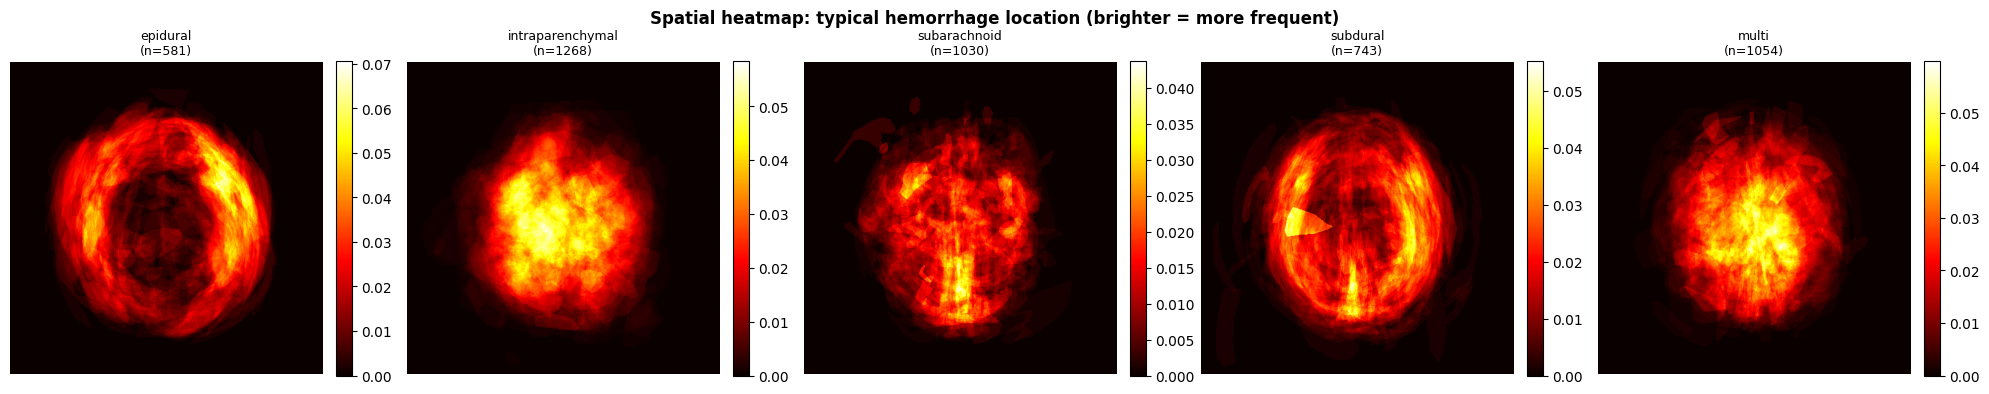

In [13]:
# Spatial heatmaps — where do hemorrhages typically appear?
if heatmaps:
    n_types = len(heatmaps)
    fig, axes = plt.subplots(1, n_types, figsize=(4 * n_types, 4))
    if n_types == 1:
        axes = [axes]
    for ax, (ht, hmap) in zip(axes, heatmaps.items()):
        norm_hmap = hmap / heatmap_counts[ht]
        im = ax.imshow(norm_hmap, cmap="hot", vmin=0, vmax=norm_hmap.max())
        ax.set_title(f"{ht}\n(n={heatmap_counts[ht]})", fontsize=9)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle("Spatial heatmap: typical hemorrhage location (brighter = more frequent)",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()

## 6. Candidate Transformations

Below we apply 5 candidate transformations to a sample image and compare visually. These are not necessarily applied to the final pipeline — the goal is to see whether any would help disambiguate hemorrhage from background.

In [14]:
def apply_clahe(img_gray, clip_limit=2.0, tile_grid=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    return clahe.apply(img_gray)

def apply_zscore(img_gray):
    f = img_gray.astype(np.float32)
    mu, sigma = f.mean(), f.std()
    if sigma < 1e-6:
        return img_gray
    out = (f - mu) / sigma
    # Clip to ±3σ and rescale to [0,255]
    out = np.clip(out, -3, 3)
    out = ((out + 3) / 6 * 255).astype(np.uint8)
    return out

def apply_minmax(img_gray):
    lo, hi = img_gray.min(), img_gray.max()
    if hi == lo:
        return img_gray
    return ((img_gray.astype(np.float32) - lo) / (hi - lo) * 255).astype(np.uint8)

def apply_skull_mask(img_bone):
    """Rough skull removal: threshold → largest connected component → fill."""
    _, thresh = cv2.threshold(img_bone, 15, 255, cv2.THRESH_BINARY)
    # Morphological clean-up
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    # Fill holes via flood-fill
    flood = closed.copy()
    h, w = flood.shape
    mask_ff = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, mask_ff, (0, 0), 255)
    inner = cv2.bitwise_not(flood)
    brain_mask = cv2.bitwise_or(closed, inner)
    # Erode to exclude skull ring
    eroded = cv2.erode(brain_mask, kernel, iterations=5)
    return cv2.bitwise_and(img_bone, eroded)


print("Transformation functions defined.")

Transformation functions defined.


In [15]:
# Pick 3 sample images from the first available type (prefer positive cases)
sample_images_for_transforms = []
for ht in HEMORRHAGE_TYPES:
    type_dir = RENDERS_ROOT / ht / CHANNELS[0]
    if not type_dir.exists():
        continue
    all_ids = [p.stem for p in sorted(type_dir.glob("*.jpg"))]
    # Prefer positives
    htype_col = ht if ht in labels_df.columns else None
    if htype_col:
        cands = [i for i in all_ids if i in labels_df.index and labels_df.loc[i, htype_col] == 1]
        if len(cands) >= 3:
            sample_images_for_transforms = [(random.choice(cands), ht) for _ in range(3)]
            break
    sample_images_for_transforms = [(random.choice(all_ids), ht) for _ in range(3)]
    break

print(f"Transformation samples: {sample_images_for_transforms}")

Transformation samples: [('ID_c22a3ce84', 'epidural'), ('ID_21449fbe6', 'epidural'), ('ID_07c565939', 'epidural')]


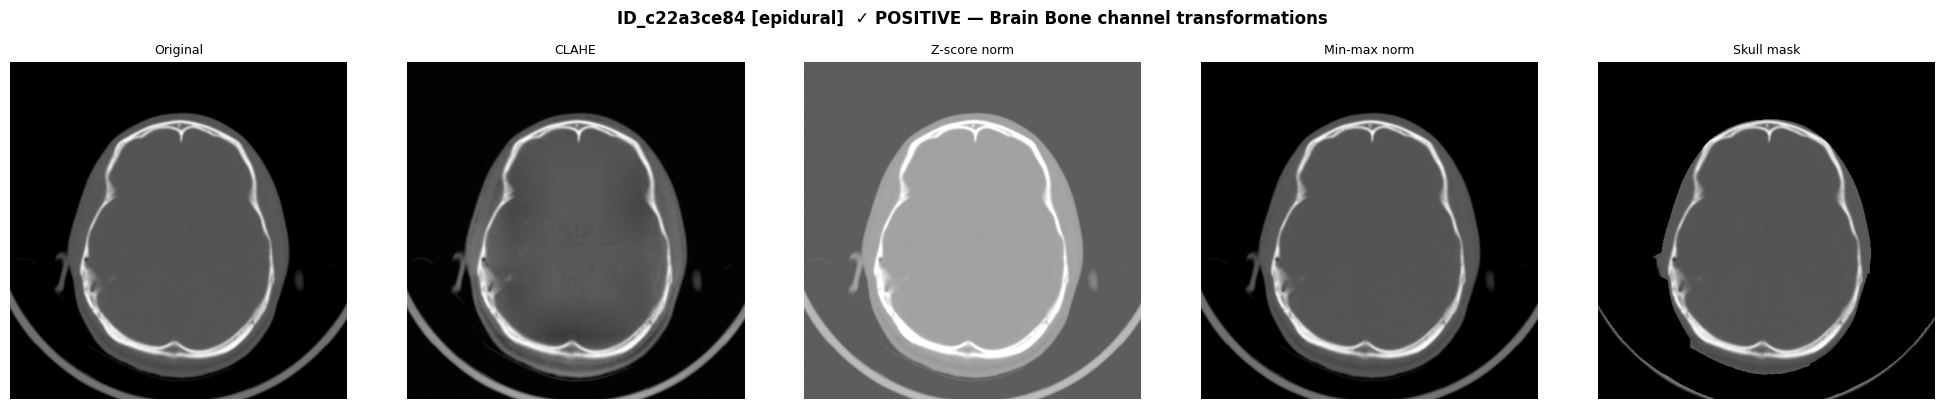

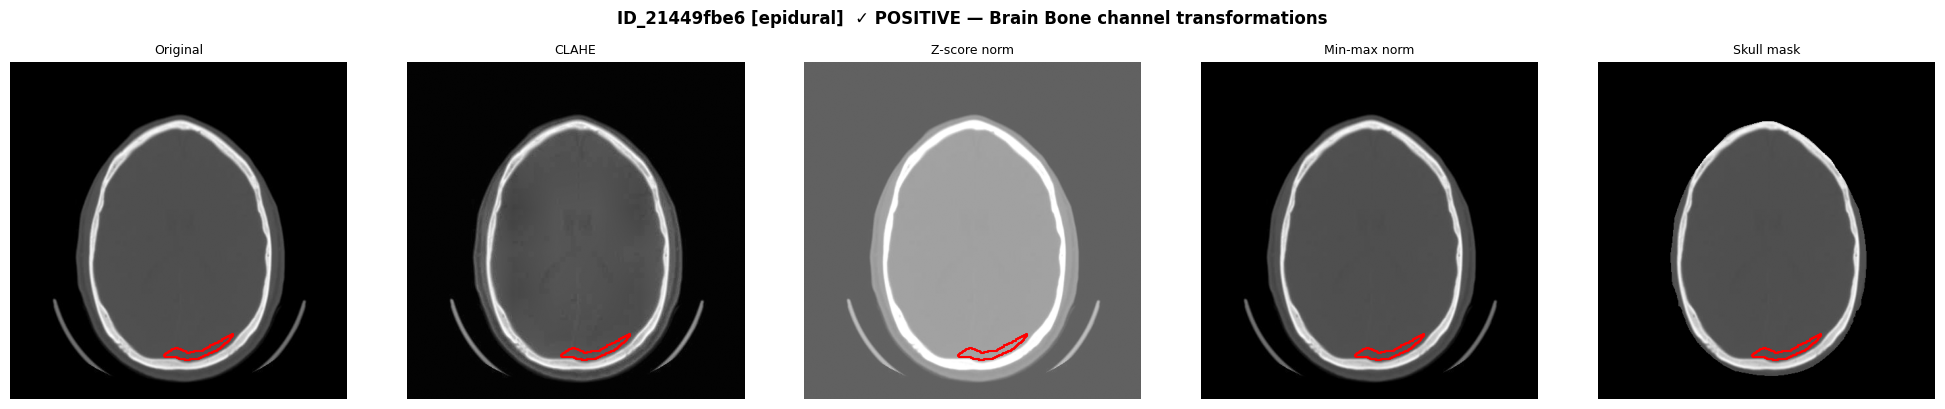

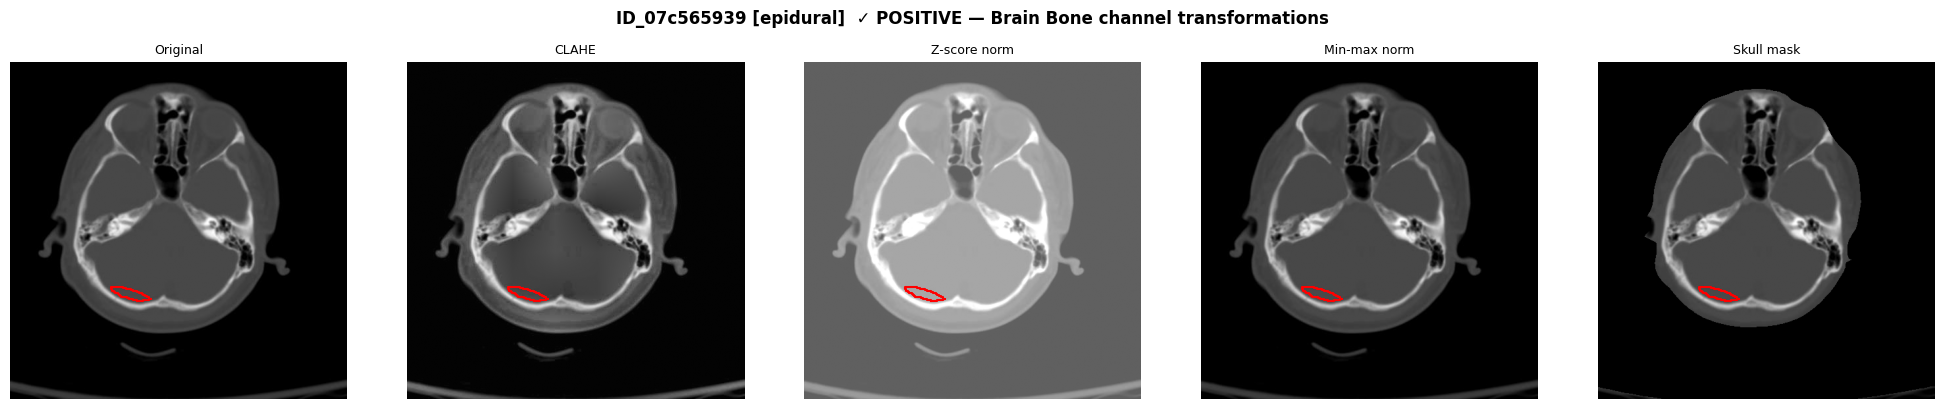

In [16]:
TRANSFORMS = [
    ("Original",         lambda g: g),
    ("CLAHE",            apply_clahe),
    ("Z-score norm",     apply_zscore),
    ("Min-max norm",     apply_minmax),
    ("Skull mask",       apply_skull_mask),
]

for img_id, ht in sample_images_for_transforms:
    img = load_image_3ch(img_id, ht)
    if img is None:
        continue

    # Use brain_bone channel (index 0) for all transforms
    brain_bone = img[:, :, 0]
    seg_row = get_seg_row(img_id)
    pts = []
    if seg_row is not None:
        for col in ["Correct Label", "Majority Label"]:
            pts = parse_polygon(str(seg_row.get(col, "nan")))
            if pts:
                break

    n_t = len(TRANSFORMS)
    fig, axes = plt.subplots(1, n_t, figsize=(4 * n_t, 4))
    for ax, (name, fn) in zip(axes, TRANSFORMS):
        transformed = fn(brain_bone)
        ax.imshow(transformed, cmap="gray", vmin=0, vmax=255)
        # Draw polygon if available
        if pts:
            xs, ys = zip(*pts)
            ax.plot(list(xs) + [xs[0]], list(ys) + [ys[0]], 'r-', linewidth=1.5)
        ax.set_title(name, fontsize=9)
        ax.axis("off")

    pos_flag = ""
    lbl = get_label_row(img_id)
    htype_col = ht if ht in labels_df.columns else None
    if lbl is not None and htype_col:
        pos_flag = "  ✓ POSITIVE" if lbl.get(htype_col, 0) == 1 else "  ✗ negative"
    fig.suptitle(f"{img_id} [{ht}]{pos_flag} — Brain Bone channel transformations",
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

### Transformation Notes

| Transformation | Rationale | Caveat |
|---|---|---|
| **CLAHE** | Enhances local contrast; may make subtle bleeds more visible | Can amplify noise in low-signal areas |
| **Z-score norm** | Removes global scanner intensity offsets; standard in medical imaging | Assumes Gaussian distribution per image |
| **Min-max norm** | Expands full dynamic range; useful if images have clipped values | Sensitive to outlier pixels |
| **Skull mask** | Removes bone artifact from brain_bone channel; reduces irrelevant signal | Rough segmentation — may clip near-skull bleeds |
| **ROI crop + resize** | If segmentation available, crop to bounding box (not shown above — requires masks) | Loses global spatial context |

## 7. Summary & Observations

*Fill in after running the notebook. Template:*

### Class Imbalance
- Most hemorrhage types are rare (<5% of all scans). Models will need class weighting or oversampling.

### Visual Observations (epidural)
- *Describe what you see from the sample visualization — location, shape, density contrast...*

### Channel Informativeness
- *Which channel shows the clearest contrast between positive and negative cases?*

### Recommended Transformations to Test
- [ ] CLAHE on all channels (especially brain_bone)
- [ ] Z-score normalization per channel before feeding to neural networks
- [ ] Skull stripping — worth testing if brain_bone features dominate
- [ ] No transformation baseline — always compare against raw input

### Data Quality Notes
- *Any low-difficulty or low-agreement cases? Any obvious mislabels?*